# IMDB Sentiment Analysis
NLP project comparing three approaches for binary sentiment classification
(positive/negative) on 50,000 IMDB movie reviews.

**Models compared:**
- MLP + TF-IDF (baseline)
- GRU + Word Embedding (deep learning)
- BERT fine-tuned (transformer)

**Dataset**: [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

---
# 1) Load Data
Loading the dataset and performing initial inspection.
50,000 reviews — perfectly balanced: 25,000 positive, 25,000 negative.
No class imbalance issues.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('IMDB Dataset.csv', engine='python', on_bad_lines='skip')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


---
# 2) EDA
Exploring text characteristics before preprocessing.

**Key findings:**
- Reviews contain HTML tags (e.g. `<br />`) → must be cleaned
- Average review length: ~231 words, 95th percentile: 590 words → max_length=500 for padding
- Top words are dominated by stopwords (the, a, and) → must be removed
- No difference in length between positive and negative reviews
  → length alone cannot predict sentiment

In [2]:
print(df.shape)
df.info()
df['sentiment'].value_counts()

(50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,count
sentiment,
positive,25000
negative,25000


In [3]:
# example
print("=== Positive Review ===")
print(df[df['sentiment'] == 'positive']['review'].iloc[0][:300])
print("\n=== Negative Review ===")
print(df[df['sentiment'] == 'negative']['review'].iloc[0][:300])

=== Positive Review ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

=== Negative Review ===
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to ma


In [4]:
# review length
df['review_length'] = df['review'].apply(lambda x: len(x.split()))
df.groupby('sentiment')['review_length'].mean()

,review_length
sentiment,
negative,229.46456
positive,232.84932


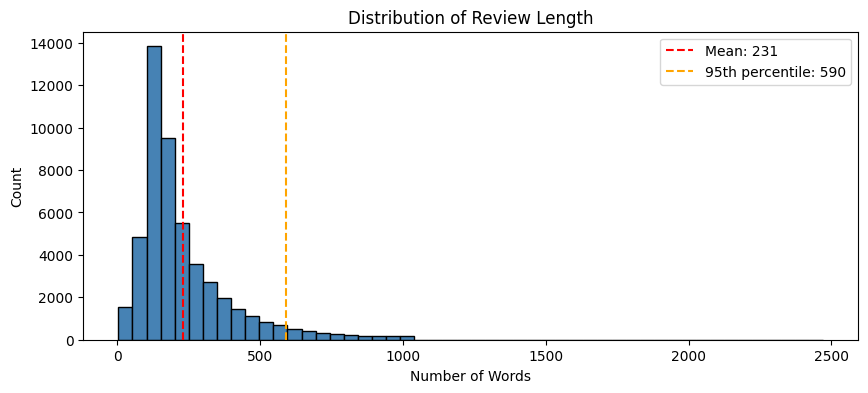

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64

95th percentile: 590
99th percentile: 908


In [5]:
# length distribution

plt.figure(figsize=(10, 4))
plt.hist(df['review_length'], bins=50, color='steelblue', edgecolor='black')
plt.axvline(df['review_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["review_length"].mean():.0f}')
plt.axvline(df['review_length'].quantile(0.95), color='orange', linestyle='--', label=f'95th percentile: {df["review_length"].quantile(0.95):.0f}')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.title('Distribution of Review Length')
plt.legend()
plt.show()

print(df['review_length'].describe())
print(f"\n95th percentile: {df['review_length'].quantile(0.95):.0f}")
print(f"99th percentile: {df['review_length'].quantile(0.99):.0f}")

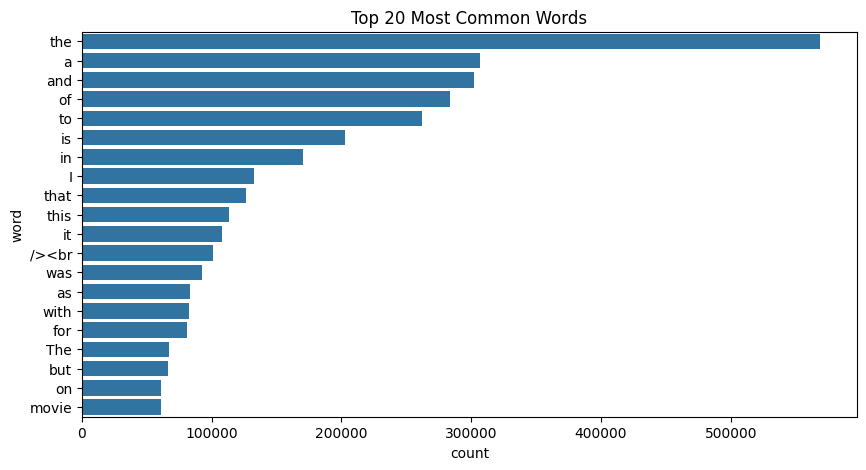

In [6]:
# top 20 most common words
from collections import Counter

all_words = ' '.join(df['review']).split()
word_counts = Counter(all_words)

common_words = pd.DataFrame(word_counts.most_common(20), columns=['word', 'count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=common_words, x='count', y='word')
plt.title('Top 20 Most Common Words')
plt.show()

---
# 3) Preprocessing
Cleaning text and preparing data for all 3 models.

**Steps:**
1. Remove HTML tags → replace with space to avoid words merging
2. Remove special characters
3. Lowercase
4. Remove stopwords → remove common words with no sentiment value
5. Encode labels → positive=1, negative=0
6. Train/test split → 80/20, split once and shared across all models
   to ensure fair comparison

In [7]:
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # lowercase
    text = text.lower()
    # stopwords
    text = ' '.join([w for w in text.split() if w not in stop_words])
    # extra whitespace
    text = text.strip()
    return text

df['cleaned_review'] = df['review'].apply(clean_text)

# Encode label
df['label'] = (df['sentiment'] == 'positive').astype(int)

# check
print("Before:", df['review'].iloc[0][:200])
print("\nAfter:", df['cleaned_review'].iloc[0][:200])
print("\nLabel sample:", df['label'].value_counts())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Before: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

After: one reviewers mentioned watching oz episode youll hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls 

Label sample: label
1    25000
0    25000
Name: count, dtype: int64


In [8]:
# Split train/test
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

---
<br/><br/><br/>
# 4) Model 1: MLP + TF-IDF
**Baseline model** — simplest approach, no sequence understanding.

TF-IDF converts each review into a 10,000-dimensional vector
where each value represents the importance of a word.
MLP then learns to classify based on these word importance scores.

**Limitation:** Treats text as a bag of words — word order is ignored.
"not good" and "good not" produce identical vectors.

In [23]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train shape:", X_train_tfidf.shape)
print("X_test shape:", X_test_tfidf.shape)

X_train shape: (40000, 10000)
X_test shape: (10000, 10000)


In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_mlp = Sequential([
    Dense(128, activation='relu', input_shape=(10000,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_mlp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,449 (4.92 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

model_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_mlp = model_mlp.fit(
    X_train_tfidf.toarray(),
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8575 - loss: 0.3357 - val_accuracy: 0.8895 - val_loss: 0.2654
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9297 - loss: 0.1861 - val_accuracy: 0.8813 - val_loss: 0.2862
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9584 - loss: 0.1160 - val_accuracy: 0.8799 - val_loss: 0.3492


In [26]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred_prob = model_mlp.predict(X_test_tfidf.toarray())
y_pred_mlp = (y_pred_prob > 0.5).astype(int)

print("=== MLP + TF-IDF ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_mlp):.4f}")
print("\n", classification_report(y_test, y_pred_mlp))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== MLP + TF-IDF ===
Accuracy : 0.8886
F1 Score : 0.8891

               precision    recall  f1-score   support

           0       0.89      0.89      0.89      4961
           1       0.89      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



---
<br><br><br>
# 5) Model 2: GRU + Embedding
**Deep learning approach** — reads words sequentially, captures order.

Instead of TF-IDF, uses a trainable Embedding layer that learns
word representations from scratch. GRU then processes the sequence
and maintains memory of previous words.

**Key fix:** padding='pre' is used so zeros appear before actual text,
ensuring GRU's final hidden state contains review information —
not zeros from padding.

In [27]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN = 500

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (40000, 500)
X_test_pad shape: (10000, 500)


In [28]:
from tensorflow.keras.layers import Embedding, GRU

model_lstm = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    GRU(64),
    Dense(1, activation='sigmoid')
])

model_lstm.summary()

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.8099 - loss: 0.4136 - val_accuracy: 0.8751 - val_loss: 0.2992
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9128 - loss: 0.2259 - val_accuracy: 0.8834 - val_loss: 0.2927
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9374 - loss: 0.1712 - val_accuracy: 0.8735 - val_loss: 0.3894
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9555 - loss: 0.1254 - val_accuracy: 0.8694 - val_loss: 0.3648


In [29]:
y_pred_prob_gru = model_lstm.predict(X_test_pad)
y_pred_gru = (y_pred_prob_gru > 0.5).astype(int)

print("=== GRU + Embedding ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_gru):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_gru):.4f}")
print("\n", classification_report(y_test, y_pred_gru))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
=== GRU + Embedding ===
Accuracy : 0.8821
F1 Score : 0.8854

               precision    recall  f1-score   support

           0       0.90      0.86      0.88      4961
           1       0.87      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



---
<br><br><br>
# 6) Model 3: BERT (Fine-tuned)
**State-of-the-art approach** — pretrained transformer model.

BERT (bert-base-uncased) was pretrained on Wikipedia and Books
using Masked Language Modeling. We fine-tune it on IMDB reviews
by adding a classification head on top of the [CLS] token.

**Why BERT is different:**
- Bidirectional — sees context from both left and right simultaneously
- Pretrained — already understands English deeply
- Attention mechanism — directly models relationships between all words
- Fine-tuning: 3 epochs, lr=2e-5 (small to preserve pretrained weights)

In [30]:
!pip install transformers torch

In [31]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
print("Tokenizer loaded!")

# check
sample = "This movie was absolutely brilliant!"
tokens = tokenizer_bert(sample, max_length=128, truncation=True,
                        padding='max_length', return_tensors='pt')
print("Input IDs shape:", tokens['input_ids'].shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded!
Input IDs shape: torch.Size([1, 128])


In [32]:
from torch.utils.data import Dataset, DataLoader
import torch

# Tokenize
def tokenize_data(texts, tokenizer, max_length=128):
    return tokenizer(
        list(texts),
        max_length=max_length,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )

print("Tokenizing train set...")
train_encodings = tokenize_data(X_train, tokenizer_bert)
print("Tokenizing test set...")
test_encodings = tokenize_data(X_test, tokenizer_bert)
print("Done!")

Tokenizing train set...
Tokenizing test set...
Done!


In [33]:
# Dataset class
class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = IMDBDataset(train_encodings, y_train)
test_dataset = IMDBDataset(test_encodings, y_test)
print("Dataset created!")
print("Train size:", len(train_dataset))

Dataset created!
Train size: 40000


In [34]:
from transformers import BertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

model_bert = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
model_bert = model_bert.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


In [35]:
# DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# Optimizer and Scheduler
optimizer = AdamW(model_bert.parameters(), lr=2e-5)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=len(train_loader) * 3  # 3 epochs
)

In [38]:
# Training loop
from sklearn.metrics import accuracy_score

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    total_steps = len(loader)

    for step, batch in enumerate(loader):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        if (step) % 100 == 0:
            current_acc = accuracy_score(all_labels, all_preds)
            avg_loss = total_loss / (step + 1)
            print(f"  Step {step}/{total_steps} — Loss: {avg_loss:.4f}, Acc: {current_acc:.4f}")

    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), acc

# Train 3 epochs
for epoch in range(3):
    loss, acc = train_epoch(model_bert, train_loader, optimizer, scheduler, device)
    print(f"Epoch {epoch+1}/3 — Loss: {loss:.4f}, Accuracy: {acc:.4f}")

  Step 0/2500 — Loss: 0.9267, Acc: 0.5000
  Step 100/2500 — Loss: 0.4322, Acc: 0.8212
  Step 200/2500 — Loss: 0.4015, Acc: 0.8321
  Step 300/2500 — Loss: 0.3841, Acc: 0.8382
  Step 400/2500 — Loss: 0.3734, Acc: 0.8424
  Step 500/2500 — Loss: 0.3686, Acc: 0.8434
  Step 600/2500 — Loss: 0.3592, Acc: 0.8496
  Step 700/2500 — Loss: 0.3514, Acc: 0.8529
  Step 800/2500 — Loss: 0.3473, Acc: 0.8543
  Step 900/2500 — Loss: 0.3433, Acc: 0.8557
  Step 1000/2500 — Loss: 0.3366, Acc: 0.8588
  Step 1100/2500 — Loss: 0.3335, Acc: 0.8601
  Step 1200/2500 — Loss: 0.3303, Acc: 0.8610
  Step 1300/2500 — Loss: 0.3285, Acc: 0.8624
  Step 1400/2500 — Loss: 0.3269, Acc: 0.8634
  Step 1500/2500 — Loss: 0.3253, Acc: 0.8646
  Step 1600/2500 — Loss: 0.3234, Acc: 0.8654
  Step 1700/2500 — Loss: 0.3205, Acc: 0.8666
  Step 1800/2500 — Loss: 0.3191, Acc: 0.8675
  Step 1900/2500 — Loss: 0.3177, Acc: 0.8683
  Step 2000/2500 — Loss: 0.3156, Acc: 0.8691
  Step 2100/2500 — Loss: 0.3135, Acc: 0.8701
  Step 2200/2500 — Los

In [39]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for step, batch in enumerate(loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

            if (step + 1) % 100 == 0:
                print(f"  Step {step+1}/{len(loader)}")

    return all_preds, all_labels

print("Evaluating on test set...")
y_pred_bert, y_true_bert = evaluate(model_bert, test_loader, device)

print("\n=== BERT ===")
print(f"Accuracy : {accuracy_score(y_true_bert, y_pred_bert):.4f}")
print(f"F1 Score : {f1_score(y_true_bert, y_pred_bert):.4f}")
print("\n", classification_report(y_true_bert, y_pred_bert))

Evaluating on test set...
  Step 100/625
  Step 200/625
  Step 300/625
  Step 400/625
  Step 500/625
  Step 600/625

=== BERT ===
Accuracy : 0.8991
F1 Score : 0.9004

               precision    recall  f1-score   support

           0       0.90      0.89      0.90      4961
           1       0.90      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



---
<br><br><br>
# 7) Results & Comparison
Evaluating all 3 models on the same test set (10,000 reviews)
using Accuracy and F1 Score, followed by a visual comparison.

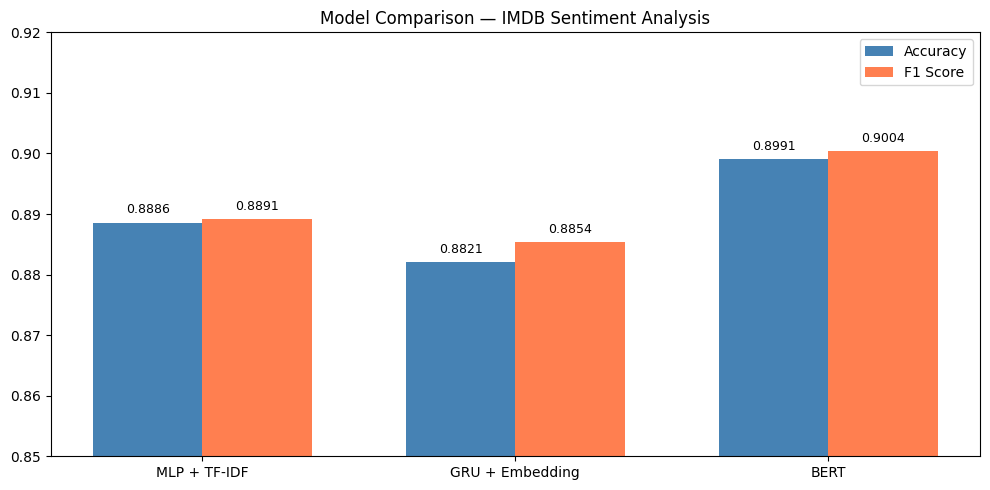

In [43]:
# Final comparison bar chart
models_name = ['MLP + TF-IDF', 'GRU + Embedding', 'BERT']
accuracies = [0.8886, 0.8821, 0.8991]
f1_scores  = [0.8891, 0.8854, 0.9004]

x = np.arange(len(models_name))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='coral')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models_name)
ax.set_ylim(0.85, 0.92)
ax.set_title('Model Comparison — IMDB Sentiment Analysis')
ax.legend()
plt.tight_layout()
plt.show()

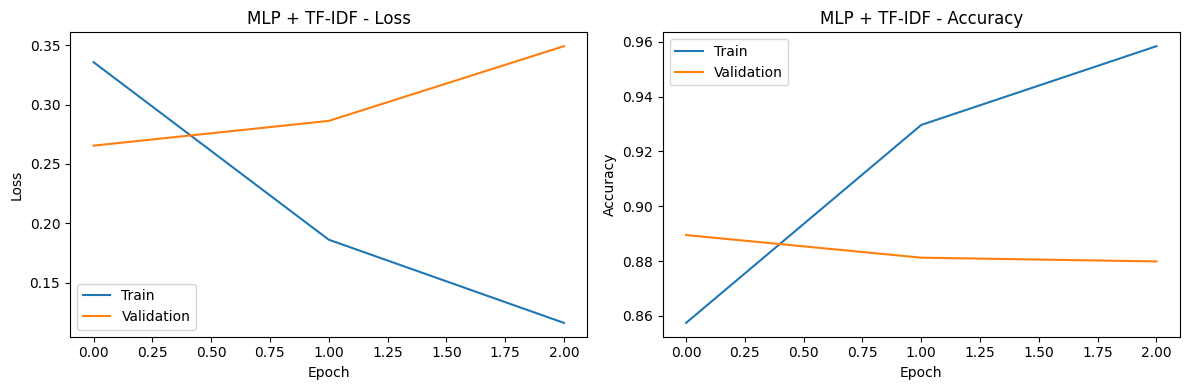

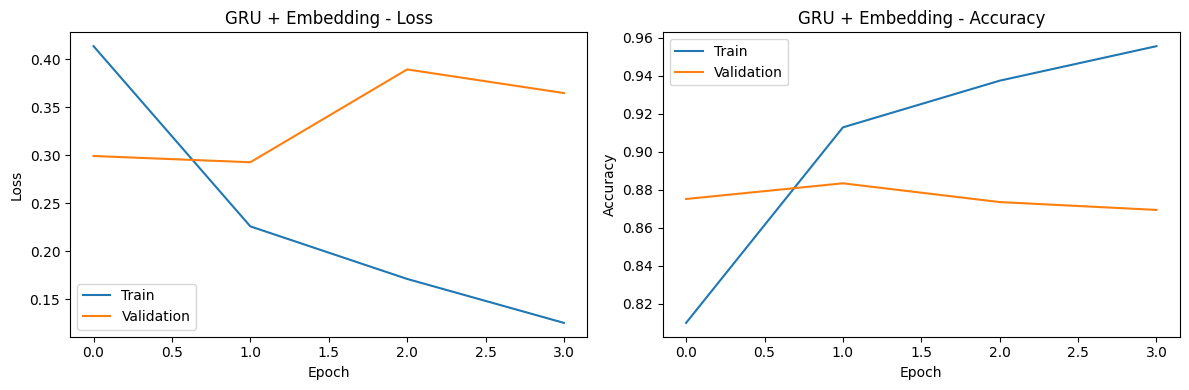

In [42]:
# Plot training history
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train')
    ax1.plot(history.history['val_loss'], label='Validation')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train')
    ax2.plot(history.history['val_accuracy'], label='Validation')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_mlp, 'MLP + TF-IDF')
plot_history(history_lstm, 'GRU + Embedding')

---
<br><br><br>
# 8) Inference
Testing all 3 models on challenging real-world examples
including sarcasm, double negatives, and mixed sentiment
to understand each model's linguistic capabilities beyond accuracy metrics.

In [47]:
def predict_sentiment_all(text,
                           model_mlp, tfidf,
                           model_gru, tokenizer_seq,
                           model_bert, tokenizer_bert, device,
                           expected):

    cleaned = clean_text(text)

    # MLP prediction
    tfidf_vec = tfidf.transform([cleaned])
    mlp_prob = model_mlp.predict(tfidf_vec.toarray(), verbose=0)[0][0]
    mlp_pred = "Positive ✅" if mlp_prob > 0.5 else "Negative ❌"

    # GRU prediction
    seq = tokenizer_seq.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=500, padding='pre', truncating='pre')
    gru_prob = model_lstm.predict(pad, verbose=0)[0][0]
    gru_pred = "Positive ✅" if gru_prob > 0.5 else "Negative ❌"

    # BERT prediction
    model_bert.eval()
    tokens = tokenizer_bert(
        text, max_length=128, truncation=True,
        padding='max_length', return_tensors='pt'
    ).to(device)
    with torch.no_grad():
        output = model_bert(**tokens)
        bert_pred_idx = output.logits.argmax(dim=1).item()
    bert_pred = "Positive ✅" if bert_pred_idx == 1 else "Negative ❌"

    # Print result
    print(f"Review   : {text}")
    print(f"Expected : {expected}")
    print(f"MLP      : {mlp_pred}")
    print(f"GRU      : {gru_pred}")
    print(f"BERT     : {bert_pred}")
    print()

# Test cases
test_cases = [
    ("Oh great, another superhero movie. Just what the world needed.",
     "Negative ❌ (sarcasm)"),

    ("I wouldn't say this film is not without its charm.",
     "Positive ✅ (double negative)"),

    ("The first half was painfully slow and boring, but the ending completely blew me away.",
     "Positive ✅ (mixed → ends positive)"),

    ("Beautiful cinematography, stellar cast, amazing soundtrack... and yet somehow still managed to be dull.",
     "Negative ❌ (mixed → ends negative)"),

    ("The acting was fine. The story was fine. Everything was just... fine.",
     "Negative ❌ (subtle dissatisfaction)"),

    ("I cried throughout the entire movie, but not because it was sad — because it was so unbearably bad.",
     "Negative ❌ (complex negation)"),

    ("This is not the worst film I have ever seen, but it is close.",
     "Negative ❌ (negation)"),

    ("It tries so hard to be profound that it forgets to be entertaining.",
     "Negative ❌ (subtle negative)"),
]

print("=" * 60)
for text, expected in test_cases:
    predict_sentiment_all(
        text,
        model_mlp, tfidf,
        model_lstm, tokenizer,
        model_bert, tokenizer_bert, device,
        expected
    )

Review   : Oh great, another superhero movie. Just what the world needed.
Expected : Negative ❌ (sarcasm)
MLP      : Positive ✅
GRU      : Positive ✅
BERT     : Positive ✅

Review   : I wouldn't say this film is not without its charm.
Expected : Positive ✅ (double negative)
MLP      : Negative ❌
GRU      : Positive ✅
BERT     : Positive ✅

Review   : The first half was painfully slow and boring, but the ending completely blew me away.
Expected : Positive ✅ (mixed → ends positive)
MLP      : Negative ❌
GRU      : Negative ❌
BERT     : Positive ✅

Review   : Beautiful cinematography, stellar cast, amazing soundtrack... and yet somehow still managed to be dull.
Expected : Negative ❌ (mixed → ends negative)
MLP      : Positive ✅
GRU      : Positive ✅
BERT     : Negative ❌

Review   : The acting was fine. The story was fine. Everything was just... fine.
Expected : Negative ❌ (subtle dissatisfaction)
MLP      : Positive ✅
GRU      : Positive ✅
BERT     : Positive ✅

Review   : I cried throug

---
# Conclusion

## Results Summary

| Model | Accuracy | F1 |
|-------|----------|-----|
| MLP + TF-IDF | 0.8886 | 0.8891 |
| GRU + Embedding | 0.8821 | 0.8854 |
| **BERT (fine-tuned)** | **0.8991** | **0.9004** |

## Key Findings

**MLP outperforms GRU** — sentiment classification relies more on
keyword presence than word order. TF-IDF captures this effectively
without the complexity of sequential modeling.

**BERT achieves the best results** (+1%) by understanding bidirectional
context and leveraging pretrained language knowledge.

**Performance vs compute trade-off:**
- MLP: ~16 sec training → 88.9% accuracy
- GRU: ~30 sec training → 88.2% accuracy
- BERT: ~50 min training → 90.0% accuracy

A 1% gain requires significantly more compute —
in production, this trade-off must be carefully considered.

<br><br><br>
## Inference on Challenging Cases

| Case | MLP | GRU | BERT |
|------|-----|-----|------|
| Sarcasm | ❌ | ❌ | ❌ |
| Double negative | ❌ | ✅ | ✅ |
| Mixed → ends positive | ❌ | ❌ | ✅ |
| Mixed → ends negative | ❌ | ❌ | ✅ |
| Subtle dissatisfaction | ❌ | ❌ | ❌ |
| Complex negation | ✅ | ✅ | ✅ |
| Negation | ✅ | ✅ | ✅ |
| Subtle negative | ❌ | ❌ | ✅ |
| **Score** | **2/8** | **3/8** | **6/8** |

**What all models struggle with:**
- Sarcasm — positive words ("great", "needed") dominate the signal
- Subtle dissatisfaction — "fine" repeated appears positive on the surface

**Where BERT clearly outperforms:**
- Mixed sentiment requiring full-sentence context understanding
- Subtle negative tone without explicit negative words
- Double negatives requiring logical reasoning

**Key takeaway:** 90% test accuracy does not mean the model
understands language like a human. All 3 models fail on sarcasm —
a task that requires world knowledge and pragmatic understanding
beyond what can be learned from text alone.
True language understanding remains an open challenge in NLP.